## Import libraries

In [5]:
import pandas as pd
import numpy as np
from pandas import DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

## Data collection

In [23]:
# Load the dataset from the provided URL
url = "Heart Prediction Quantum Dataset.csv"
df = pd.read_csv(url)

# Display the first few rows of the dataset
print(df.head())

   Age  Gender  BloodPressure  Cholesterol  HeartRate  QuantumPatternFeature  \
0   68       1            105          191        107               8.362241   
1   58       0             97          249         89               9.249002   
2   44       0             93          190         82               7.942542   
3   72       1             93          183        101               6.495155   
4   37       0            145          166        103               7.653900   

   HeartDisease  
0             1  
1             0  
2             1  
3             1  
4             1  


## Data Exploration

In [24]:
# Print all column names in the dataset
print(df.columns)

Index(['Age', 'Gender', 'BloodPressure', 'Cholesterol', 'HeartRate',
       'QuantumPatternFeature', 'HeartDisease'],
      dtype='object')


In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Gender                 500 non-null    int64  
 2   BloodPressure          500 non-null    int64  
 3   Cholesterol            500 non-null    int64  
 4   HeartRate              500 non-null    int64  
 5   QuantumPatternFeature  500 non-null    float64
 6   HeartDisease           500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB
None


In [26]:
print(df.iloc())

In [27]:
#comparison operators and maskking
mask = df['Age'] > 50
print(mask)

0       True
1       True
2      False
3       True
4      False
       ...  
495    False
496    False
497    False
498     True
499     True
Name: Age, Length: 500, dtype: bool


Age                      0
Gender                   0
BloodPressure            0
Cholesterol              0
HeartRate                0
QuantumPatternFeature    0
HeartDisease             0
dtype: int64
HeartDisease
1    300
0    200
Name: count, dtype: int64


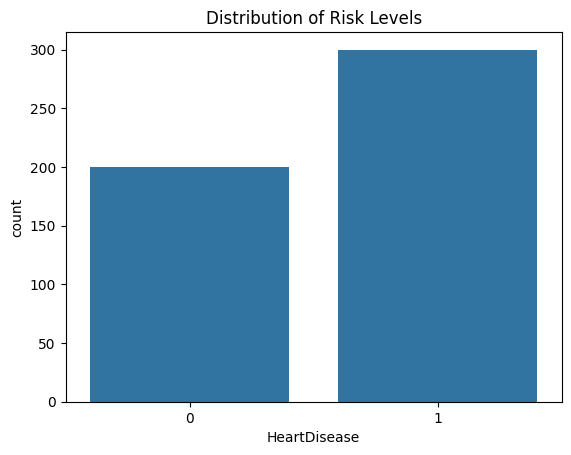

In [29]:
# Checking for missing values
print(df.isnull().sum())

# Checking the distribution of the target variable
target_column = 'HeartDisease'  
print(df[target_column].value_counts())

# Visualizing the target variable distribution
sns.countplot(x=target_column, data=df)
plt.title('Distribution of Risk Levels')
plt.show()

## Data Preprocessing

In [30]:
# getting duplicated values
print(df.duplicated())

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool


In [31]:
df.drop_duplicates(inplace=True)

In [32]:
# checking if duplicated values still exist
print(df.duplicated())

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool


## Feature engineering

In [ ]:
# Separating features (X) and target (y)
X = df.drop(columns=['HeartDisease'])  # Assuming 'HeartDisease' is the target column
y = df['HeartDisease']

In [39]:
# Converting categorical variables to numerical (if any)
X = pd.get_dummies(X, drop_first=True)

In [40]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Handle Imbalanced Data

In [11]:
# Check the class distribution in the training set
print(y_train.value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check the new class distribution after SMOTE
print(pd.Series(y_train_res).value_counts())

Heart_Risk
1.0    28000
0.0    28000
Name: count, dtype: int64
Heart_Risk
1.0    28000
0.0    28000
Name: count, dtype: int64


In [ ]:
## Model Training

In [12]:
# Train a Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_res, y_train_res)

# Alternatively, train a Random Forest model
# model = RandomForestClassifier(random_state=42)
# model.fit(X_train_res, y_train_res)

LogisticRegression(random_state=42)

## Model Evaluation

Confusion Matrix:
[[6940   60]
 [  64 6936]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      7000
         1.0       0.99      0.99      0.99      7000

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000

ROC-AUC Score: 0.9994969591836734


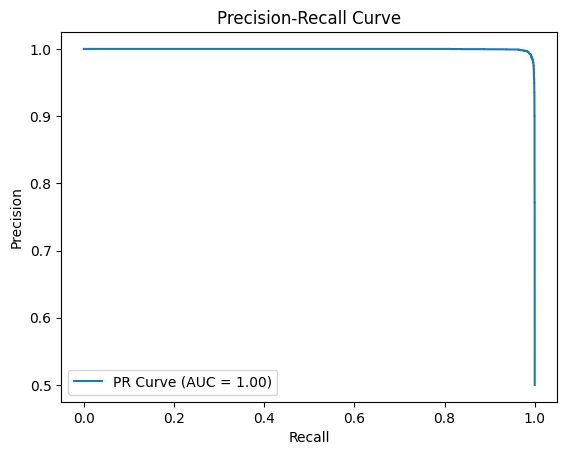

In [13]:
# Predict on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc}")

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## Feature Importance

In [15]:
# For Random Forest, visualize feature importance
if isinstance(model, RandomForestClassifier):
    feature_importance = model.feature_importances_
    feature_names = X.columns
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title('Feature Importance')
    plt.show()

## Save the Model

In [16]:
import joblib

# Save the trained model
joblib.dump(model, 'heart_disease_risk_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

## Model deployment